In [1]:
def MAPE(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

In [2]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import cross_validate

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

In [3]:
#from sklearn.metrics import mean_absolute_percentage_error

In [4]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None, ic_=None):
    if (pd_ == None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    elif (pd_ != None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    elif (pd_ != None) and (ic_ != None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_, index_col = ic_)
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), index_col = ic_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)
    
#sort dataframe by column
def s(df_, column_):
    return df_.sort_values(column_)

#reset index and sort dataframe by column
def sr(df_, column_, ascending_=True):
    df_ = df_.sort_values(column_, ascending=ascending_)
    return df_.reset_index(drop=True)

#print length of list
def pl(list_):
    print(len(list_))
    return list_

#print length of dictionary
def pdc(dict_):
    print(len(dict_))
    return dict_

## 5.4 Load Model<a id='5.4_Load_Model'></a>

In [5]:
# This isn't exactly production-grade, but a quick check for development
# These checks can save some head-scratching in development when moving from
# one python environment to another, for example
expected_model_version = '1.0'
model_path = os.path.join('..','models', 'nba_spread_a_model_161.pkl')
if os.path.exists(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    if model.version != expected_model_version:
        print("Expected model version doesn't match version loaded")
    if model.sklearn_version != sklearn_version:
        print("Warning: model created under different sklearn version")
else:
    print("Expected model not found")

In [6]:
model_161 = model
model_161

Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(max_depth=10, min_samples_split=100,
                                       n_estimators=200, random_state=47))])

In [7]:
model_161.named_steps.randomforestregressor.feature_importances_

array([1.13563127e-01, 5.25973771e-03, 3.66332429e-03, 7.95375880e-04,
       1.40491124e-03, 1.09308598e-02, 1.86588247e-03, 2.44420692e-03,
       1.53886554e-03, 1.89079640e-03, 1.52546443e-02, 2.74749460e-05,
       1.23179730e-03, 4.79968187e-04, 9.82168132e-04, 5.97728251e-04,
       6.20408209e-04, 6.18506343e-04, 4.79328441e-04, 8.15433374e-04,
       1.12316450e-03, 4.97718122e-04, 8.49207016e-04, 6.17303152e-04,
       3.62127234e-04, 5.46369808e-04, 8.51129397e-04, 1.59556969e-03,
       9.55794475e-04, 6.41210800e-04, 4.48632834e-04, 2.93646354e-04,
       1.90921022e-04, 1.13351243e-03, 9.17032370e-04, 1.04985522e-03,
       4.05321701e-04, 2.35060393e-04, 4.71636442e-04, 6.01702362e-04,
       5.49128826e-04, 3.30618589e-04, 9.86137778e-04, 4.76795624e-04,
       3.87905329e-04, 7.51709043e-04, 3.81492536e-04, 3.80213347e-04,
       5.58880880e-04, 7.74414060e-04, 7.17101214e-04, 1.70084800e-03,
       5.01791028e-04, 6.89712722e-04, 2.76778814e-04, 4.12339330e-04,
      

In [ ]:
model_161.X_columns

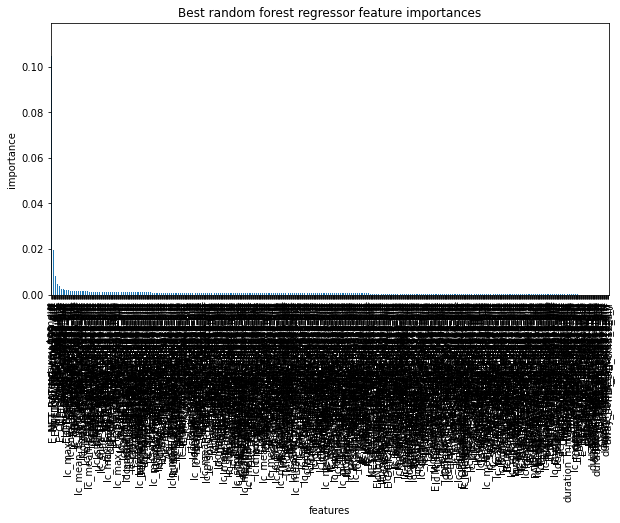

In [9]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(10, 5))
imps = model_161.named_steps.randomforestregressor.feature_importances_
rf_feat_imps = pd.Series(imps, index=model_161.X_columns).sort_values(ascending=False)
rf_feat_imps.plot(kind='bar')
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Best random forest regressor feature importances');

In [12]:
print(len(rf_feat_imps[0:50]))
rf_feat_imps[0:50]

50


away_home_a                          0.113563
spread_cma999_diff                   0.104860
NET_RATING_cma999_diff               0.085476
E_NET_RATING_cma999_diff             0.080330
PIE_cma999_diff                      0.019765
strength_of_schedule_diff            0.015255
opp_losses_diff                      0.010931
E_NET_RATING_cma12_diff              0.008064
losses_diff                          0.005260
PIE_cma12_diff                       0.004878
w_pct_cma5_diff_y                    0.004793
w_pct_cma5_diff_x                    0.004722
spread_cma12_diff                    0.004417
wins_diff                            0.003663
w_pct_cmax5_diff_y                   0.002975
E_OFF_RATING_cma999_diff             0.002521
NET_RATING_cma12_diff                0.002516
EFG_PCT_cma999_diff                  0.002499
pf_cma999_diff                       0.002449
opp_opps_losses_diff                 0.002444
TS_PCT_cma999_diff                   0.002354
w_pct_cmax5_diff_x                

In [7]:
df_train = rcp('161_train_split.csv', None, 0)
p(df_train)

(7186, 841)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff,spread_a
3134,-0.999416,1.099997,-1.006300,-0.869106,0.869106,-1.099997,1.006300,-0.446871,-1.416010,-0.196035,...,0.681655,-1.529913,0.347225,1.073355,1.120699,0.670210,-0.018242,0.800259,-0.480626,11
8383,-0.999416,-1.376256,1.381831,1.147929,-1.147929,1.376256,-1.381831,-1.074563,1.622779,0.541892,...,0.822020,0.882326,-0.004867,-0.341903,-0.861733,-2.815468,-0.223585,-0.786289,-0.970517,-10
7423,-0.999416,-0.614332,0.617629,0.321641,-0.321641,0.614332,-0.617629,2.156205,-0.839025,-0.291209,...,-0.641787,-1.132292,-1.614433,-0.398513,-1.297868,0.016646,-0.037798,-0.714716,1.478941,22
2528,-0.999416,0.147592,-0.242098,-0.605934,0.605934,-0.147592,0.242098,0.125436,-0.031245,-0.757113,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,10
10064,-0.999416,1.385719,-1.388401,-0.777675,0.777675,-1.385719,1.388401,2.137743,-0.781326,-0.260570,...,0.398060,-0.321900,-1.528206,-1.805683,0.520305,-0.774746,-0.624492,1.636988,-0.270672,4
3378,1.000585,1.004757,-0.910774,-0.595496,0.595496,-1.004757,0.910774,0.993128,-0.858258,-0.209483,...,-0.289963,-1.556421,0.280465,1.363611,-1.369957,-0.997370,0.808996,1.480208,0.855443,-5
1965,1.000585,-0.614332,0.426579,0.488491,-0.488491,0.614332,-0.426579,0.402359,0.468809,-0.000505,...,0.461081,-1.344357,-1.010846,0.733693,-2.209787,0.514600,-0.546266,-1.012939,0.499158,14
1161,-0.999416,0.528554,-0.528673,-0.300758,0.300758,-0.528554,0.528673,-0.188410,-0.569765,-0.042986,...,-1.403768,0.511212,-0.457557,-0.624954,-0.980679,-0.325698,-0.282254,0.287315,0.009266,-8
2771,-0.999416,0.433314,-0.528673,-0.729611,0.729611,-0.433314,0.528673,0.771590,-0.165875,-0.721090,...,1.062646,0.378671,-1.362938,0.507252,2.072266,0.234500,-1.103625,0.740614,0.499158,-4
9937,1.000585,-0.900053,0.904205,0.538977,-0.538977,0.900053,-0.904205,-0.059179,-1.185216,-0.131998,...,-0.842308,-1.476897,1.504101,-1.134447,-0.267004,0.514600,-1.005843,-0.237558,1.478941,-8


In [8]:
df_test = rcp('161_test_split.csv', None, 0)
p(df_test)

(3080, 841)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff,spread_a
2583,1.000585,-0.328610,0.426579,1.350913,-1.350913,0.328610,-0.426579,0.070052,-0.031245,-0.273612,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,7
9370,-0.999416,1.385719,-1.388401,-1.970642,1.970642,-1.385719,1.388401,0.771590,-0.762094,-0.970663,...,-1.463925,-2.033568,-0.407258,-2.889366,-1.734003,-3.033323,-2.384573,1.170055,1.968833,15
5655,-0.999416,1.385719,-1.770502,-1.539212,1.539212,-1.385719,1.770502,1.362359,-0.127410,-0.408668,...,-1.075642,0.684720,1.197735,-0.722736,0.140296,0.141134,0.169322,1.661311,-1.193195,-1
7258,1.000585,-2.614383,2.623659,1.681878,-1.681878,2.614383,-2.623659,-0.705333,-0.877491,-0.030213,...,1.944940,-0.177999,-0.859949,0.944695,-1.957478,-1.539461,0.079540,-2.623345,0.855443,-5
2386,1.000585,0.052352,-0.051047,-0.051521,0.051521,-0.052352,0.051047,0.014667,0.007220,-0.013957,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,-10
8109,-0.999416,0.528554,-0.624199,-0.788287,0.788287,-0.528554,0.624199,0.014667,0.314946,0.153835,...,0.541290,0.670261,-0.105465,1.299796,1.120699,-0.263454,-0.164915,-0.523853,0.009266,2
9743,1.000585,-0.328610,0.331054,0.243728,-0.243728,0.328610,-0.331054,-1.499179,0.853465,0.406982,...,0.260560,1.465504,-1.564134,0.563862,1.398239,-0.885896,1.174702,-1.358878,0.009266,24
4546,1.000585,1.004757,-0.910774,-0.694836,0.694836,-1.004757,0.910774,-0.188410,0.103385,0.029099,...,0.681655,-0.310540,0.799916,-0.511734,0.407023,-0.450186,-0.380036,0.943406,0.499158,6
4962,-0.999416,0.623795,-0.624199,-0.319306,0.319306,-0.623795,0.624199,0.476205,-1.377545,-0.130825,...,0.922281,2.101699,-1.463536,2.375392,0.327726,0.203378,1.252928,-2.181974,2.458724,10
5706,-0.999416,0.242833,-0.146573,-0.192442,0.192442,-0.242833,0.146573,-0.114564,0.353411,0.091763,...,-0.461318,1.757094,-1.061144,0.054369,-3.438895,-1.134873,1.712504,-1.144157,0.989049,5


In [9]:
X_train = df_train.drop(columns = 'spread_a')
p(X_train)

(7186, 840)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
3134,-0.999416,1.099997,-1.006300,-0.869106,0.869106,-1.099997,1.006300,-0.446871,-1.416010,-0.196035,...,0.130110,0.681655,-1.529913,0.347225,1.073355,1.120699,0.670210,-0.018242,0.800259,-0.480626
8383,-0.999416,-1.376256,1.381831,1.147929,-1.147929,1.376256,-1.381831,-1.074563,1.622779,0.541892,...,-0.585219,0.822020,0.882326,-0.004867,-0.341903,-0.861733,-2.815468,-0.223585,-0.786289,-0.970517
7423,-0.999416,-0.614332,0.617629,0.321641,-0.321641,0.614332,-0.617629,2.156205,-0.839025,-0.291209,...,-0.134827,-0.641787,-1.132292,-1.614433,-0.398513,-1.297868,0.016646,-0.037798,-0.714716,1.478941
2528,-0.999416,0.147592,-0.242098,-0.605934,0.605934,-0.147592,0.242098,0.125436,-0.031245,-0.757113,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
10064,-0.999416,1.385719,-1.388401,-0.777675,0.777675,-1.385719,1.388401,2.137743,-0.781326,-0.260570,...,0.043060,0.398060,-0.321900,-1.528206,-1.805683,0.520305,-0.774746,-0.624492,1.636988,-0.270672
3378,1.000585,1.004757,-0.910774,-0.595496,0.595496,-1.004757,0.910774,0.993128,-0.858258,-0.209483,...,-1.305366,-0.289963,-1.556421,0.280465,1.363611,-1.369957,-0.997370,0.808996,1.480208,0.855443
1965,1.000585,-0.614332,0.426579,0.488491,-0.488491,0.614332,-0.426579,0.402359,0.468809,-0.000505,...,0.289072,0.461081,-1.344357,-1.010846,0.733693,-2.209787,0.514600,-0.546266,-1.012939,0.499158
1161,-0.999416,0.528554,-0.528673,-0.300758,0.300758,-0.528554,0.528673,-0.188410,-0.569765,-0.042986,...,-0.982624,-1.403768,0.511212,-0.457557,-0.624954,-0.980679,-0.325698,-0.282254,0.287315,0.009266
2771,-0.999416,0.433314,-0.528673,-0.729611,0.729611,-0.433314,0.528673,0.771590,-0.165875,-0.721090,...,0.474528,1.062646,0.378671,-1.362938,0.507252,2.072266,0.234500,-1.103625,0.740614,0.499158
9937,1.000585,-0.900053,0.904205,0.538977,-0.538977,0.900053,-0.904205,-0.059179,-1.185216,-0.131998,...,-0.744181,-0.842308,-1.476897,1.504101,-1.134447,-0.267004,0.514600,-1.005843,-0.237558,1.478941


In [10]:
y_train = df_train.spread_a
p(y_train)

(7186,)


3134     11
8383    -10
7423     22
2528     10
10064     4
3378     -5
1965     14
1161     -8
2771     -4
9937     -8
Name: spread_a, dtype: int64

In [11]:
X_test = df_test.drop(columns = 'spread_a')
p(X_test)

(3080, 840)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
2583,1.000585,-0.328610,0.426579,1.350913,-1.350913,0.328610,-0.426579,0.070052,-0.031245,-0.273612,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
9370,-0.999416,1.385719,-1.388401,-1.970642,1.970642,-1.385719,1.388401,0.771590,-0.762094,-0.970663,...,-1.538992,-1.463925,-2.033568,-0.407258,-2.889366,-1.734003,-3.033323,-2.384573,1.170055,1.968833
5655,-0.999416,1.385719,-1.770502,-1.539212,1.539212,-1.385719,1.770502,1.362359,-0.127410,-0.408668,...,-1.156038,-1.075642,0.684720,1.197735,-0.722736,0.140296,0.141134,0.169322,1.661311,-1.193195
7258,1.000585,-2.614383,2.623659,1.681878,-1.681878,2.614383,-2.623659,-0.705333,-0.877491,-0.030213,...,2.117137,1.944940,-0.177999,-0.859949,0.944695,-1.957478,-1.539461,0.079540,-2.623345,0.855443
2386,1.000585,0.052352,-0.051047,-0.051521,0.051521,-0.052352,0.051047,0.014667,0.007220,-0.013957,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
8109,-0.999416,0.528554,-0.624199,-0.788287,0.788287,-0.528554,0.624199,0.014667,0.314946,0.153835,...,0.606997,0.541290,0.670261,-0.105465,1.299796,1.120699,-0.263454,-0.164915,-0.523853,0.009266
9743,1.000585,-0.328610,0.331054,0.243728,-0.243728,0.328610,-0.331054,-1.499179,0.853465,0.406982,...,0.209591,0.260560,1.465504,-1.564134,0.563862,1.398239,-0.885896,1.174702,-1.358878,0.009266
4546,1.000585,1.004757,-0.910774,-0.694836,0.694836,-1.004757,0.910774,-0.188410,0.103385,0.029099,...,0.262579,0.681655,-0.310540,0.799916,-0.511734,0.407023,-0.450186,-0.380036,0.943406,0.499158
4962,-0.999416,0.623795,-0.624199,-0.319306,0.319306,-0.623795,0.624199,0.476205,-1.377545,-0.130825,...,2.355580,0.922281,2.101699,-1.463536,2.375392,0.327726,0.203378,1.252928,-2.181974,2.458724
5706,-0.999416,0.242833,-0.146573,-0.192442,0.192442,-0.242833,0.146573,-0.114564,0.353411,0.091763,...,-0.267295,-0.461318,1.757094,-1.061144,0.054369,-3.438895,-1.134873,1.712504,-1.144157,0.989049


In [12]:
y_test = df_test.spread_a
p(y_test)

(3080,)


2583     7
9370    15
5655    -1
7258    -5
2386   -10
8109     2
9743    24
4546     6
4962    10
5706     5
Name: spread_a, dtype: int64

In [13]:
y_train_pred = model.predict(X_train)
y_train_pred

ValueError: Number of features of the model must match the input. Model n_features is 852 and input n_features is 840 

In [ ]:
mean_absolute_error(y_train, y_train_pred)

In [ ]:
MAPE(y_train, y_train_pred)

In [ ]:
y_test_pred = model.predict(X_test)
y_test_pred

In [ ]:
mean_absolute_error(y_test, y_test_pred)

In [ ]:
MAPE(y_test, y_test_pred)

In [ ]:
imps = model.named_steps.randomforestregressor.feature_importances_
rf_feat_imps = pd.Series(imps, index=X_train.columns).sort_values(ascending=False)

In [ ]:
rf_feat_imps[0:30]

In [ ]:
plt.scatter(y_train, y_train_pred, alpha=0.2)

In [ ]:
mean_absolute_error(y_train, y_train_pred)

In [ ]:
y_test_pred = model.predict(X_test)
y_test_pred

In [ ]:
plt.scatter(y_test, y_test_pred, alpha=0.2)

In [ ]:
mean_absolute_error(y_test, y_test_pred)

## 5.6 Refit Model

In [ ]:
X = X_train
y = y_train

In [ ]:
len(X), len(y)

In [ ]:
model.fit(X, y)

In [ ]:
cv_results = cross_validate(model, X, y, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

In [ ]:
cv_results['test_score']

<font color='red'> why is there is such large numbers in this test_score? what does it mean? I thought we'd get smaller numbers like in RF_pipe of '04_preprocessing_and_training'<font>

In [ ]:
mae_mean, mae_std = np.mean(-1 * cv_results['test_score']), np.std(-1 * cv_results['test_score'])
mae_mean, mae_std

These numbers will inevitably be different to those in the previous step that used a different training data set. They should, however, be consistent. It's important to appreciate that estimates of model performance are subject to the noise and uncertainty of data!

In [ ]:
print(f'Expected mean absolute error is {mae_mean:.2f} points.')

This result should be looked at optimistically and doubtfully! The validity of our model lies in the assumption that other resorts accurately set their prices according to what the market (the ticket-buying public) supports. The fact that our resort seems to be charging that much less that what's predicted suggests our resort might be undercharging. 
But if ours is mispricing itself, are others? It's reasonable to expect that some resorts will be "overpriced" and some "underpriced." Or if resorts are pretty good at pricing strategies, it could be that our model is simply lacking some key data? Certainly we know nothing about operating costs, for example, and they would surely help.

## 5.11 Further work<a id='5.11_Further_work'></a>

**Q: 2** What next? Highlight any deficiencies in the data that hampered or limited this work. The only price data in our dataset were ticket prices. You were provided with information about the additional operating cost of the new chair lift, but what other cost information would be useful? Big Mountain was already fairly high on some of the league charts of facilities offered, but why was its modeled price so much higher than its current price? Would this mismatch come as a surprise to the business executives? How would you find out? Assuming the business leaders felt this model was useful, how would the business make use of it? Would you expect them to come to you every time they wanted to test a new combination of parameters in a scenario? We hope you would have better things to do, so how might this model be made available for business analysts to use and explore?

**A: 2** Your answer here

**Q: 2** What next? Highlight any deficiencies in the data that hampered or limited this work. The only price data in our dataset were ticket prices. You were provided with information about the additional operating cost of the new chair lift, but what other cost information would be useful? Big Mountain was already fairly high on some of the league charts of facilities offered, but why was its modeled price so much higher than its current price? Would this mismatch come as a surprise to the business executives? How would you find out? Assuming the business leaders felt this model was useful, how would the business make use of it? Would you expect them to come to you every time they wanted to test a new combination of parameters in a scenario? We hope you would have better things to do, so how might this model be made available for business analysts to use and explore?

What next? Highlight any deficiencies in the data that hampered or limited this work. The only price data in our dataset were ticket prices.
<br>-One of the deficiencies in the data included knowing we have 350,000 visitors per season, but not knowing the precise behavior of visitor purchaser behavior like number of day tickets purchased and therefore making an assumption (of 5) on the average number of day tickets purchased per season per vistor.v

You were provided with information about the additional operating cost of the new chair lift, but what other cost information would be useful?
<br>-It would be useful to have information about the location of the this new chair lift in addition to its operating cost. Information of interest about the chair lift per se include speed of chair lift and number of chairs of the chair lift. Other information of interest include elevation spanned by the chairlift and number of runs the chair lift would add to Big Mountain Resort.
<br>-Also, it would be useful to have information about the number of tickets each person purchased each season.


Big Mountain was already fairly high on some of the league charts of facilities offered, but why was its modeled price so much higher than its current price?
<br>-Big Mountain's model price was higher than it's current price maybe because the state of Montana charges less for vistor day ticket.

Would this mismatch come as a surprise to the business executives? 
<br>-Maybe

How would you find out?
<br>-by asking

Assuming the business leaders felt this model was useful, how would the business make use of it? 
<br>-They could look into increasing vertical_drop, Snow Making_ac, total_chairs, fastQuads, Runs, LongestRun_mi, trams, and/or SkiableTerrain_ac and see if it would be the desireable and profitable to take on that scenario using our model.

Would you expect them to come to you every time they wanted to test a new combination of parameters in a scenario?
<br>-Maybe

We hope you would have better things to do, so how might this model be made available for business analysts to use and explore?
<br>-This model can be used and shared via github or other software for business analysts to use and explored.